In [1706]:
# 1. Pull BTC spot price and volume data

import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 365,
    "interval": "daily"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

In [1707]:
prices_raw = pd.DataFrame(
    data['prices'],
    columns=['timestamp', 'price']
)
prices = prices_raw.copy()

prices['date'] = pd.to_datetime(
    prices['timestamp'],
    unit='ms'
)

prices = prices[['date', 'price']]

In [1708]:
prices['daily_return'] = prices['price'].pct_change().fillna(0)

prices = prices.set_index('date')
prices.index = prices.index.normalize()
prices = prices.groupby(prices.index).last()

In [1709]:
prices['7d_return'] = prices['price'].pct_change(7)
prices['30d_return'] = prices['price'].pct_change(30)

In [1710]:
prices['rolling_vol_7d'] = prices['daily_return'].rolling(7).std()

In [1711]:
prices['ma_7'] = prices['price'].rolling(7).mean()
prices['ma_30'] = prices['price'].rolling(30).mean()

In [1712]:
prices['signal'] = 'Neutral'

prices.loc[prices['7d_return'] > 0.05, 'signal'] = 'Strong Momentum'
prices.loc[prices['7d_return'] < -0.05, 'signal'] = 'Weak Momentum'

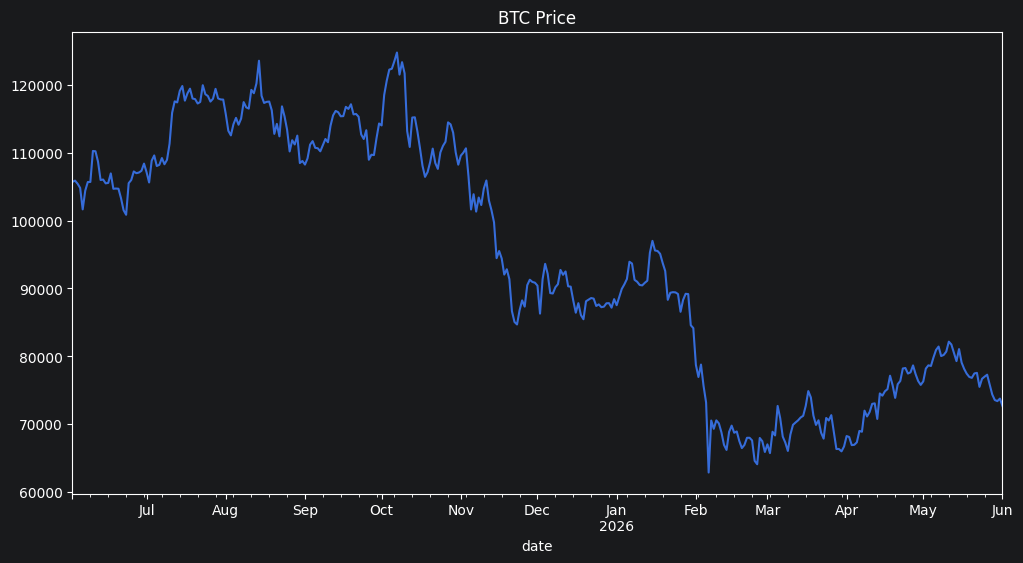

In [1713]:
prices['price'].plot(figsize=(12,6))
plt.title('BTC Price')
plt.show()

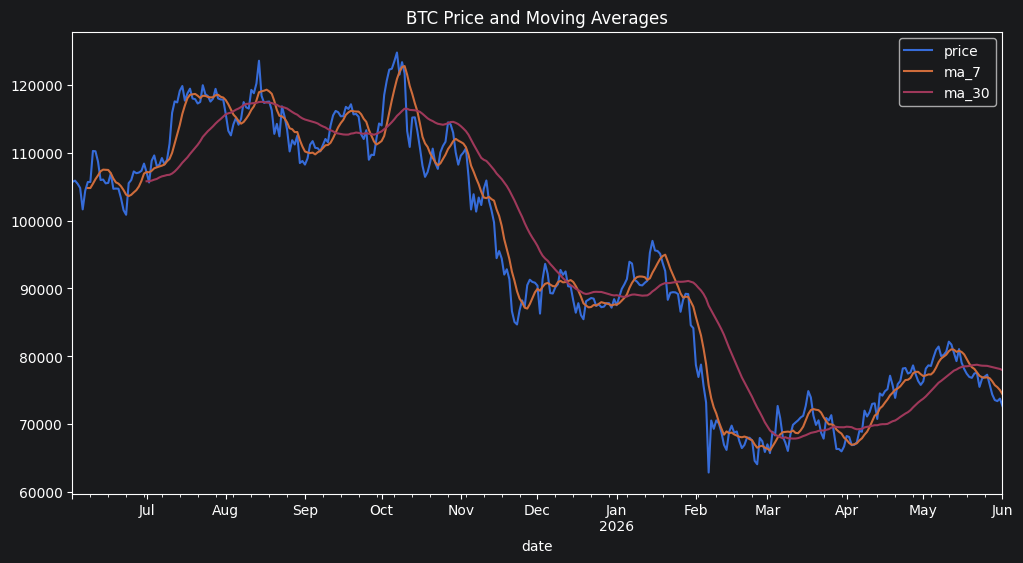

In [1714]:
prices[['price','ma_7', 'ma_30']].plot(figsize=(12,6))
plt.title('BTC Price and Moving Averages')
plt.show()

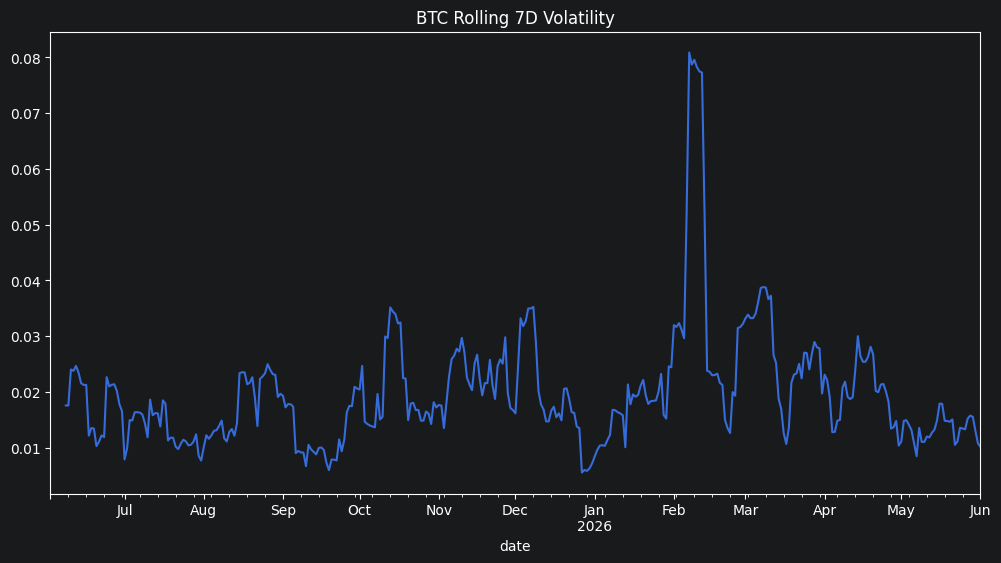

In [1715]:
prices['rolling_vol_7d'].plot(figsize=(12,6))
plt.title('BTC Rolling 7D Volatility')
plt.show()

In [1716]:
volumes_raw = pd.DataFrame(
    data['total_volumes'],
    columns=['timestamp', 'volume']
)
volumes = volumes_raw.copy()

volumes['date'] = pd.to_datetime(
    volumes['timestamp'],
    unit='ms'
)

volumes = volumes[['date', 'volume']].set_index('date')

In [1717]:
prices = prices.merge(volumes, on='date', how='left', validate='one_to_one')

In [1718]:
prices['volumes_ma_7'] = prices['volume'].rolling(7).mean()

In [1719]:
prices['volume_signal'] = 'normal'

prices.loc[
    prices['volume'] > prices['volumes_ma_7']*1.5,
    'volume_signal'
] = 'Elevated Activity'

In [1720]:
volume_mean = prices['volume'].rolling(30).mean()
volume_std = prices['volume'].rolling(30).std()
prices['volume_zscore'] = (prices['volume'] - volume_mean) / volume_std

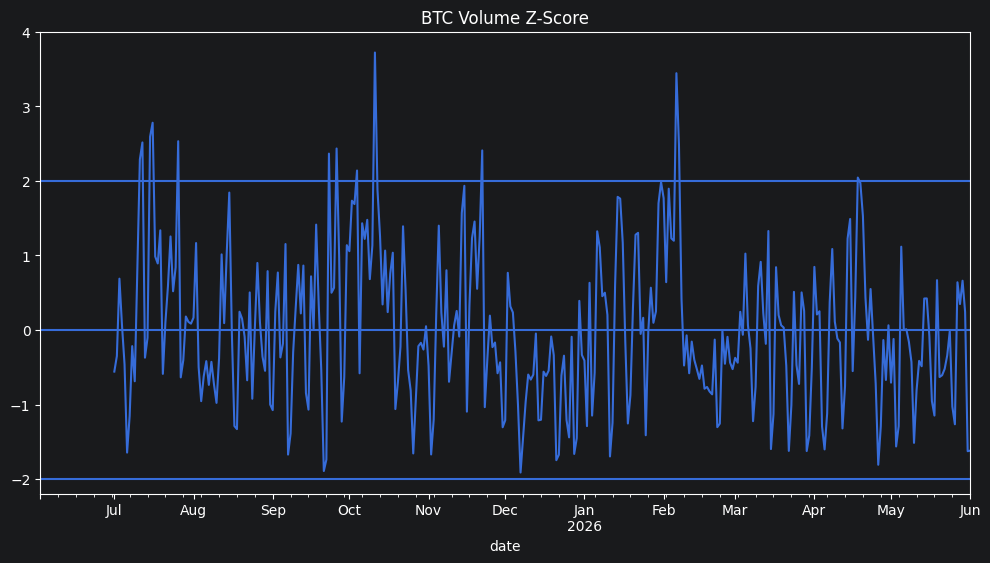

In [1721]:
prices['volume_zscore'].plot(figsize=(12,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Volume Z-Score')
plt.show()

In [1722]:
# Create spot participation signals

prices['spot_participation_signal'] = 'Neutral'

prices.loc[
    (prices['7d_return'] > 0.05) &
     (prices['volume_zscore'] > 1),
    'spot_participation_signal'
] = 'Strong Spot Participation'

prices.loc[
    (prices['7d_return'] < -0.05) &
    (prices['volume_zscore'] > 1),
    'spot_participation_signal'
] = 'High-Volume Selloff'

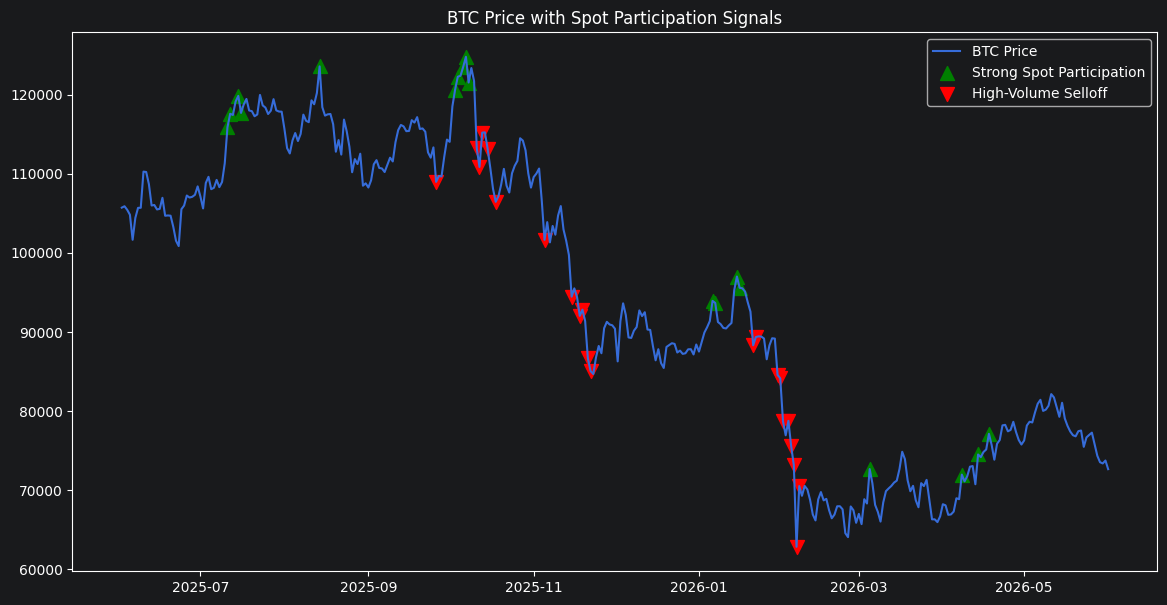

In [1723]:
strong_spot_participation = prices[prices['spot_participation_signal'] == 'Strong Spot Participation']
high_volume_selloff = prices[prices['spot_participation_signal'] == 'High-Volume Selloff']

plt.figure(figsize=(14,7))

plt.plot(prices.index,
    prices['price'],
    label='BTC Price'
)

plt.scatter(strong_spot_participation.index, strong_spot_participation['price'], label = 'Strong Spot Participation', marker = '^', color = 'green', s = 100)

plt.scatter(high_volume_selloff.index, high_volume_selloff['price'], label = 'High-Volume Selloff', marker = 'v', color = 'red', s = 100)

plt.title('BTC Price with Spot Participation Signals')
plt.legend()
plt.show()

In [1724]:
# 2. Pull BTC funding rates

hl_url = "https://api.hyperliquid.xyz/info"

end_time = int(time.time() * 1000)
start_time = end_time - (365 * 24 * 60 * 60 * 1000)

all_funding_data = []
current_start = start_time

while current_start < end_time:
    payload = {
        "type": "fundingHistory",
        "coin": "BTC",
        "startTime": current_start,
        "endTime": end_time
    }

    response = requests.post(hl_url, json=payload)
    response.raise_for_status()

    batch = response.json()

    if len(batch) == 0:
        break

    all_funding_data.extend(batch)

    last_time = batch[-1]['time']
    current_start = last_time + 1

    time.sleep(0.5)

In [1725]:
funding_raw = pd.DataFrame(all_funding_data)
funding = funding_raw.copy()

funding['time'] = pd.to_datetime(funding['time'], unit='ms')

funding['fundingRate'] = pd.to_numeric(funding['fundingRate'])

funding = funding.rename(columns={
    'time':'date',
    'fundingRate':'funding_rate'
})

funding = funding[['date', 'funding_rate']]

funding = funding.set_index('date')

daily_funding = funding.resample('D').mean()

In [1726]:
prices = prices.merge(daily_funding, on='date', how='left', validate='one_to_one')

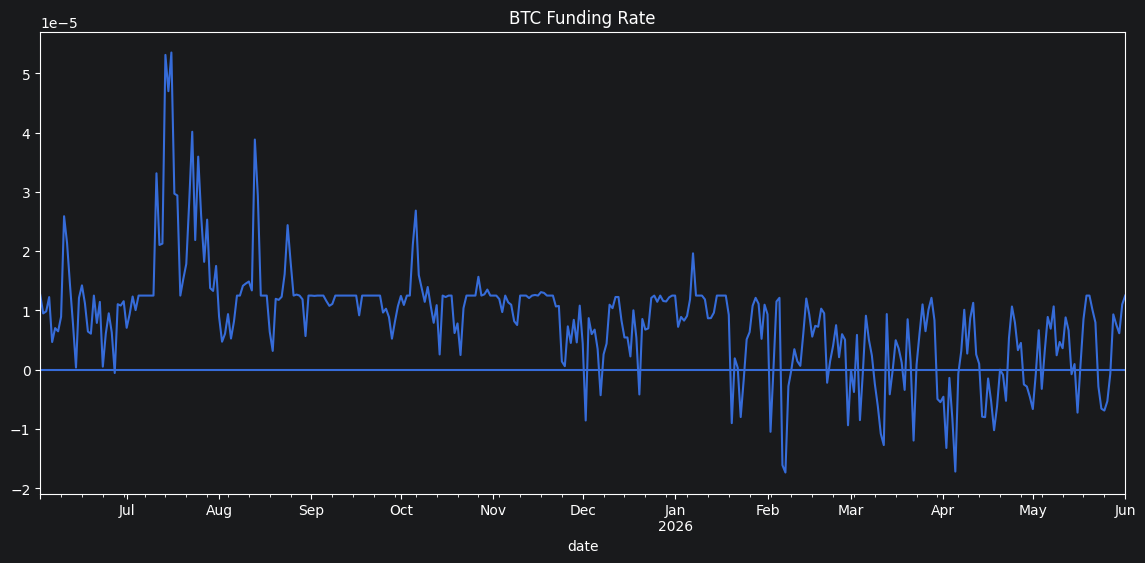

In [1727]:
prices['funding_rate'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC Funding Rate')
plt.show()

In [1728]:
prices['funding_ma_7d'] = prices['funding_rate'].rolling(7).mean()

Text(0.5, 1.0, 'BTC 7D Average Funding')

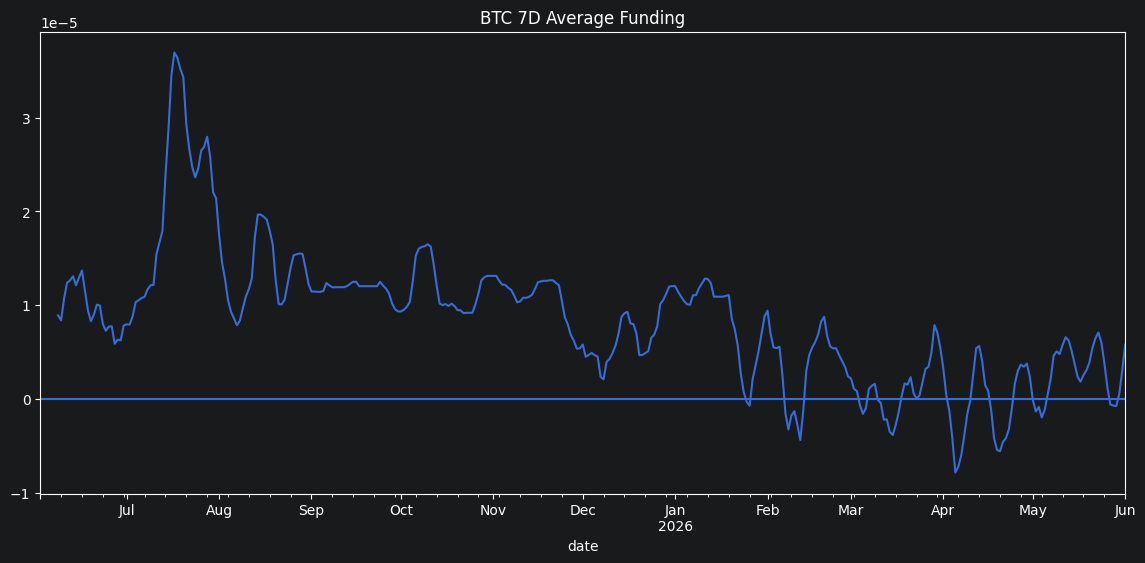

In [1729]:
prices['funding_ma_7d'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC 7D Average Funding')

In [1730]:
funding_mean = prices['funding_rate'].rolling(30).mean()
funding_std = prices['funding_rate'].rolling(30).std()
prices['funding_zscore'] = (prices['funding_rate'] - funding_mean) / funding_std

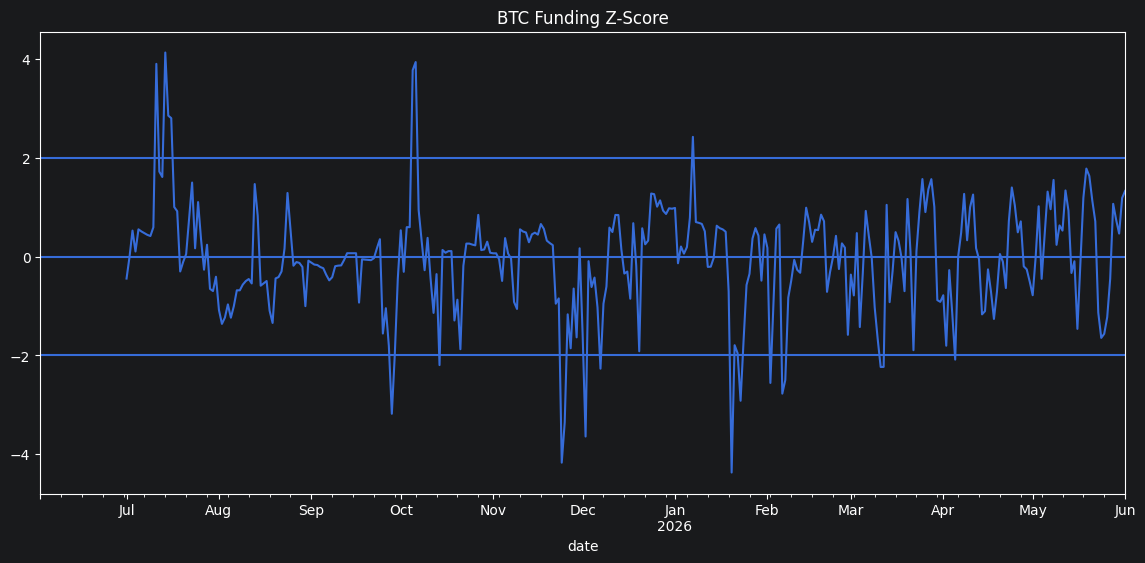

In [1731]:
prices['funding_zscore'].plot(figsize=(14,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Funding Z-Score')
plt.show()

In [1732]:
# Create Funding/Leverage Signals

prices['funding_signal'] = 'Neutral'

prices.loc[
    prices['funding_zscore'] > 2,
    'funding_signal'
] = 'Crowded Longs'

prices.loc[
    prices['funding_zscore'] < -2,
    'funding_signal'
] = 'Crowded Shorts'

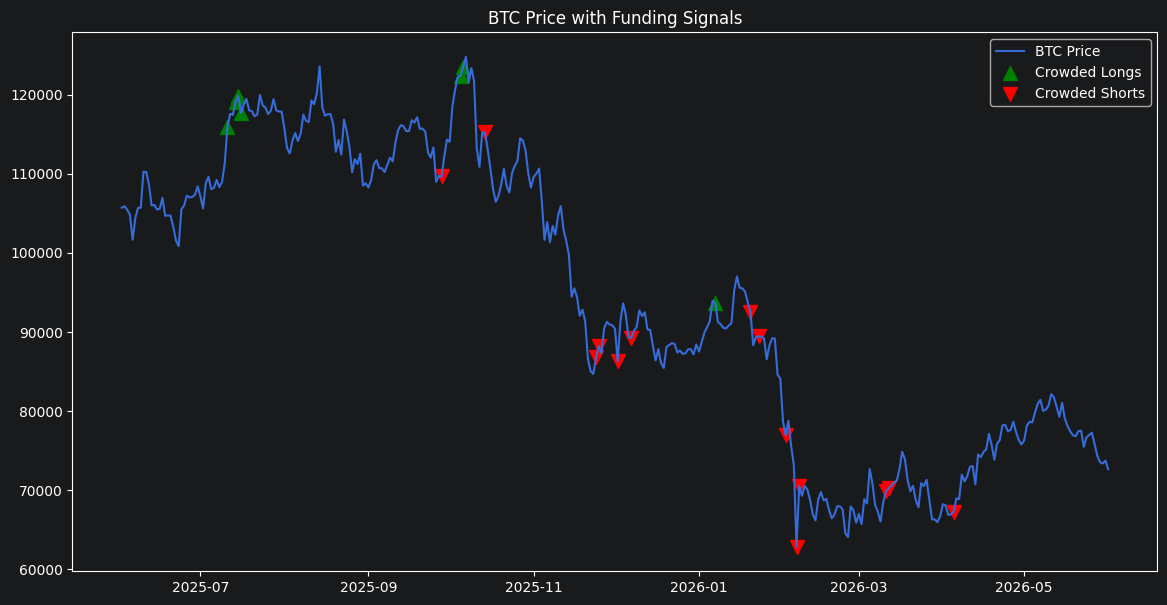

In [1733]:
# BTC Price with Funding Positioning Signals

crowded_longs = prices[
    prices['funding_signal'] == 'Crowded Longs'
]

crowded_shorts = prices[
    prices['funding_signal'] == 'Crowded Shorts'
]

plt.figure(figsize=(14,7))

# BTC Price Line
plt.plot(prices.index, prices['price'], label='BTC Price')

# Crowded Longs
plt.scatter(crowded_longs.index, crowded_longs['price'], label='Crowded Longs', marker='^', color='green', s=100)

#Crowded Shorts
plt.scatter(crowded_shorts.index, crowded_shorts['price'], label='Crowded Shorts', marker='v', color='red', s=100)

plt.title('BTC Price with Funding Signals')
plt.legend()
plt.show()

In [1734]:
# Current OI Snapshot (Hyperliquid)
# API requires pagination to retrieve full history

oi_payload = {
    "type": "metaAndAssetCtxs"
}

oi_response = requests.post(
    hl_url,
    json=oi_payload
)

oi_response.raise_for_status()

oi_data = oi_response.json()

In [1735]:
metadata = oi_data[0]['universe']

asset_contexts = oi_data[1]

btc_metadata = None
btc_oi = None

for i, asset in enumerate(metadata):
    if asset['name'] == 'BTC':
        btc_metadata = asset
        btc_oi = asset_contexts[i]
        break

btc_oi.keys()
btc_open_interest = float(
    btc_oi['openInterest']
)

oi_snapshot = pd.DataFrame({
    'date':[pd.Timestamp.today().normalize()],
    'open_interest':[btc_open_interest]
})

oi_snapshot = oi_snapshot.set_index('date')

In [1736]:
# 3. Pull BTC open interest

coinglass_url = (
    "https://open-api-v4.coinglass.com"
    "/api/futures/open-interest/history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

params = {
    "exchange": "Binance",
    "symbol": "BTCUSDT",
    "interval": "1d"
}

response = requests.get(
    coinglass_url,
    headers=headers,
    params=params
)

oi_data = response.json()

In [1737]:
oi = pd.DataFrame(oi_data['data'])

oi['time'] = pd.to_datetime(oi['time'], unit='ms')

oi[['open', 'high', 'low', 'close']] = oi[['open', 'high', 'low', 'close']].astype(float)

oi = oi.rename(columns={
    'time':'date',
    'open':'oi_open',
    'high':'oi_high',
    'low':'oi_low',
    'close':'oi_close'
})

oi = oi[['date', 'oi_open', 'oi_high', 'oi_low', 'oi_close']]

oi = oi.set_index('date')

In [1738]:
prices = prices.merge(oi[['oi_close']], on='date', how='left', validate='one_to_one')

In [1739]:
# Open Interest Analytics

prices['oi_daily_change'] = prices['oi_close'].pct_change()

prices['oi_7d_change'] = prices['oi_close'].pct_change(7)
prices['oi_30d_change'] = prices['oi_close'].pct_change(30)

In [1740]:
oi_mean = prices['oi_close'].rolling(30).mean()
oi_std = prices['oi_close'].rolling(30).std()

prices['oi_zscore'] = (prices['oi_close'] - oi_mean) / oi_std

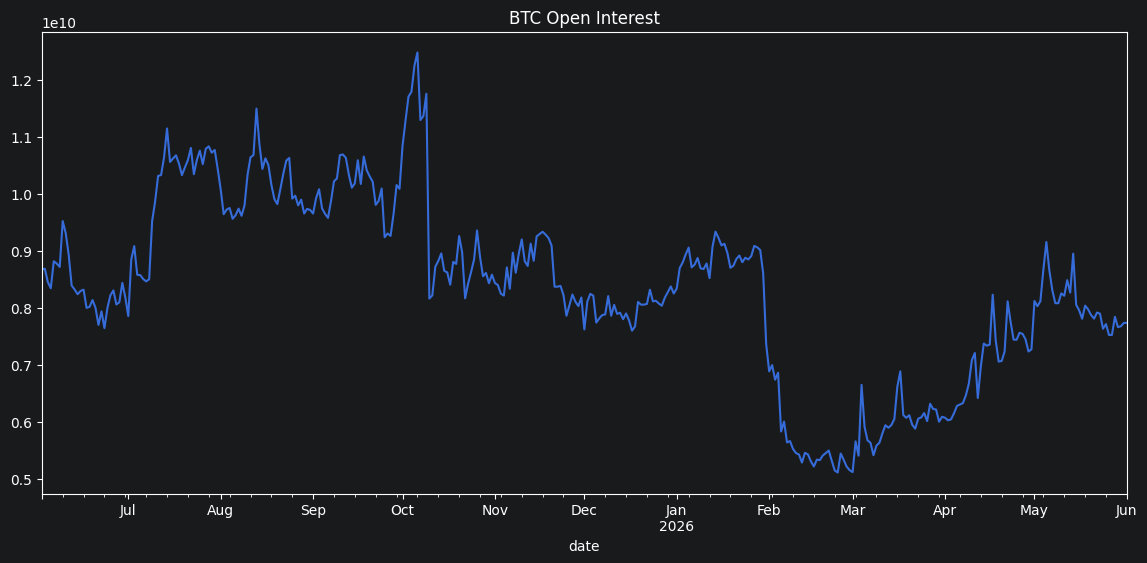

In [1741]:
# Open Interest Charts

prices['oi_close'].plot(figsize=(14,6))
plt.title('BTC Open Interest')
plt.show()

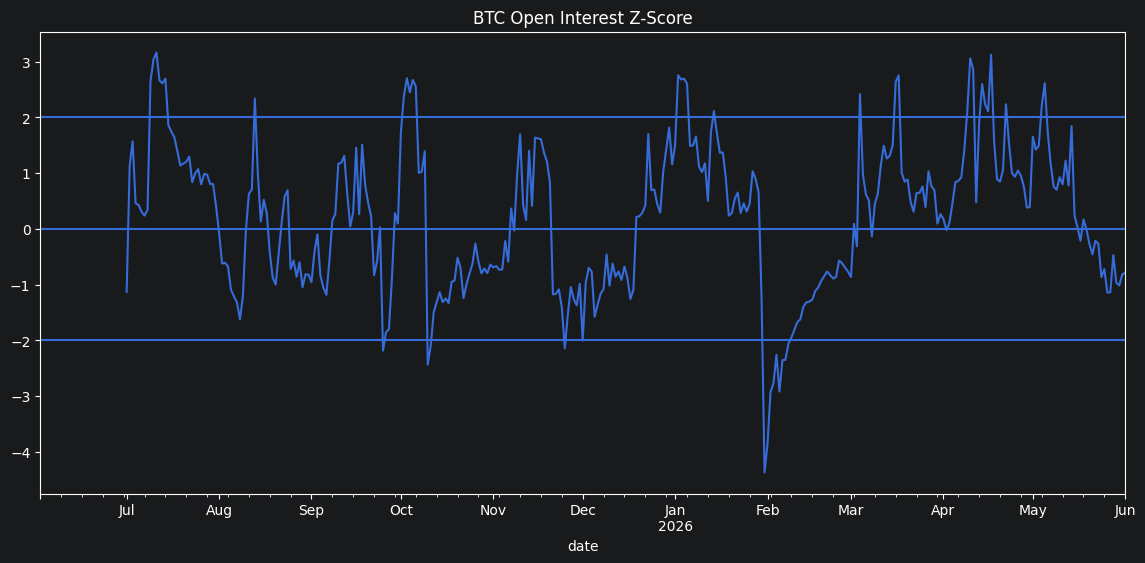

In [1742]:
prices['oi_zscore'].plot(figsize=(14,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Open Interest Z-Score')
plt.show()

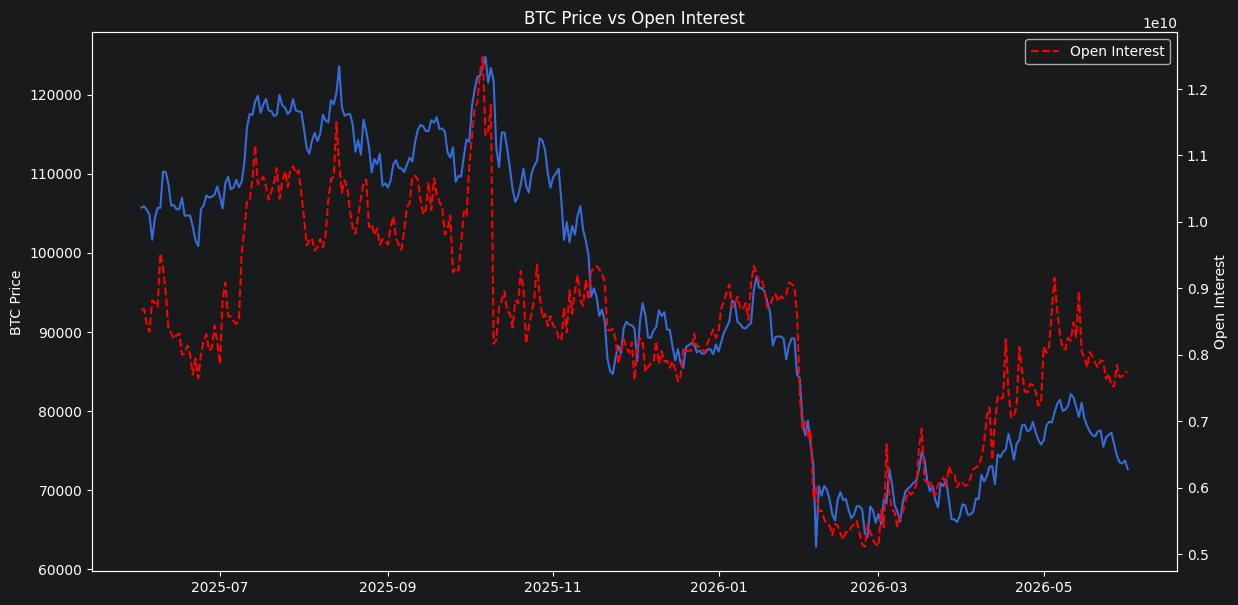

In [1743]:
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(prices.index, prices['price'], label='BTC Price')
ax1.set_ylabel('BTC Price')

ax2 = ax1.twinx()

ax2.plot(prices.index, prices['oi_close'], linestyle='--', label='Open Interest', color='red')
ax2.set_ylabel('Open Interest')

plt.title('BTC Price vs Open Interest')
plt.legend()
plt.show()

In [1744]:
# 4. Build positioning regimes

prices['leverage_signal'] = 'Neutral'

In [1745]:
# Aggressive Long Buildup
prices.loc[
    (prices['7d_return'] > 0.03) &
    (prices['funding_zscore'] > 0.5) &
    (prices['oi_7d_change'] > 0),
    'leverage_signal'
] = 'Aggressive Long Buildup'

# Short Covering Rally
prices.loc[
    (prices['7d_return'] > 0.03) &
    (prices['oi_7d_change'] < 0),
    'leverage_signal'
] = 'Short Covering Rally'

#Aggressive Short Buildup
prices.loc[
    (prices['7d_return'] < -0.03) &
    (prices['funding_zscore'] < -0.5) &
    (prices['oi_7d_change'] > 0),
    'leverage_signal'
] = 'Aggressive Short Buildup'

# Long Liquidation
prices.loc[
    (prices['7d_return'] < -0.07) &
    (prices['oi_7d_change'] < 0),
    'leverage_signal'
] = 'Long Liquidation'

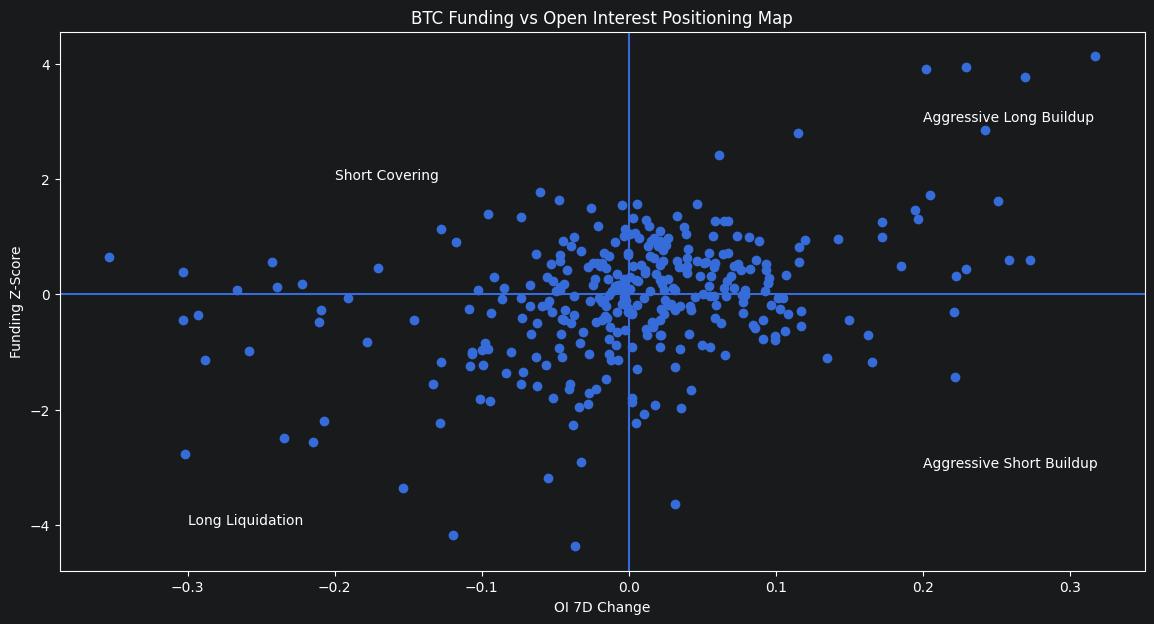

In [1746]:
# Funding z-score vs OI 7D change scatter

plt.figure(figsize=(14,7))

plt.scatter(prices['oi_7d_change'], prices['funding_zscore'])

plt.axhline(0)
plt.axvline(0)

# Quadrant Labels
plt.text(0.2, 3, 'Aggressive Long Buildup')
plt.text(0.2, -3, 'Aggressive Short Buildup')
plt.text(-0.2, 2, 'Short Covering')
plt.text(-0.3, -4, 'Long Liquidation')

plt.xlabel('OI 7D Change')
plt.ylabel('Funding Z-Score')
plt.title('BTC Funding vs Open Interest Positioning Map')

plt.show()

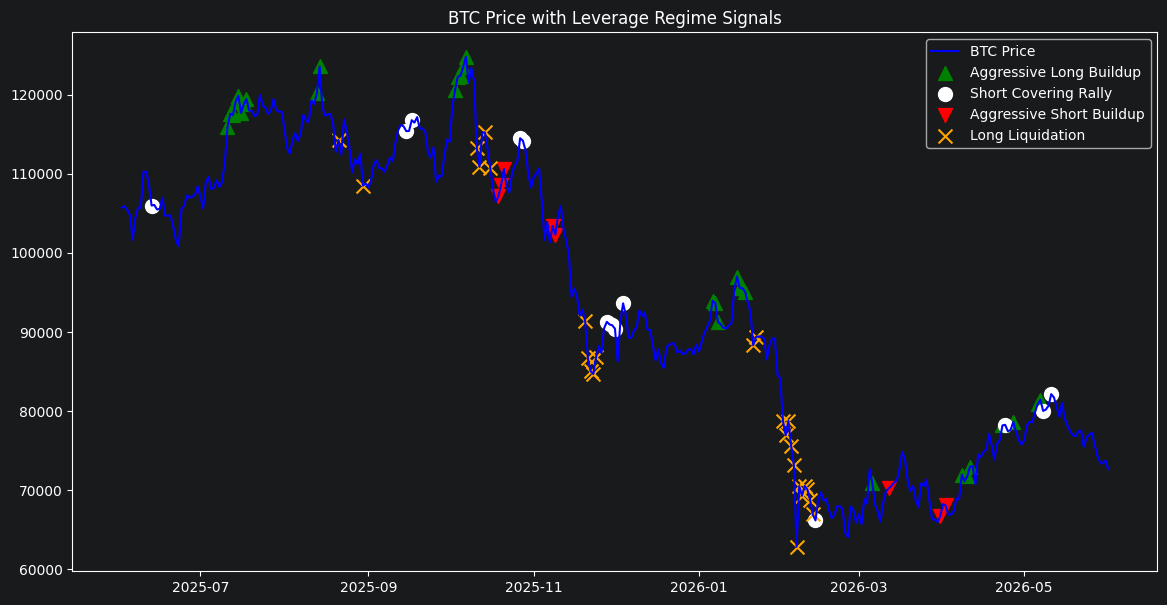

In [1778]:
# BTC Price with Leverage Regime Signals

long_buildup = prices[prices['leverage_signal'] == 'Aggressive Long Buildup']
short_covering = prices[prices['leverage_signal'] == 'Short Covering Rally']
short_buildup = prices[prices['leverage_signal'] == 'Aggressive Short Buildup']
long_liquidation = prices[prices['leverage_signal'] == 'Long Liquidation']

plt.figure(figsize=(14,7))

plt.plot(prices.index, prices['price'], label='BTC Price', color='blue')

plt.scatter(long_buildup.index, long_buildup['price'], label='Aggressive Long Buildup', marker='^', color='green', s=100)

plt.scatter(short_covering.index, short_covering['price'], label='Short Covering Rally', marker='o', color='white', s=100)

plt.scatter(short_buildup.index, short_buildup['price'], label='Aggressive Short Buildup', marker='v', color='red', s=100)

plt.scatter(long_liquidation.index, long_liquidation['price'], label='Long Liquidation', marker='x', color='orange', s=100)

plt.title('BTC Price with Leverage Regime Signals')
plt.legend()
plt.savefig(
    '../outputs/charts/leverage_regime_signals.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

In [1748]:
# 5. Pull BTC ETF flow data

etf_flow_url = (
    "https://open-api-v4.coinglass.com"
    "/api/etf/bitcoin/flow-history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

response = requests.get(
    etf_flow_url,
    headers=headers
)

etf_flow_data = response.json()

In [1749]:
etf_flows = pd.DataFrame(etf_flow_data['data'])

etf_flows['timestamp'] = pd.to_datetime(
    etf_flows['timestamp'],
    unit='ms'
)

etf_flows = etf_flows.rename(columns={
    'timestamp':'date',
    'flow_usd':'btc_etf_flow_usd',
    'price_usd':'btc_etf_price_usd'
})

etf_flows = etf_flows[
    ['date', 'btc_etf_flow_usd', 'btc_etf_price_usd']
]

etf_flows = etf_flows.set_index('date')

In [1750]:
# ETF Flow Metrics

etf_flows['btc_etf_flow_7d'] = etf_flows['btc_etf_flow_usd'].rolling(7).sum()
etf_flows['btc_etf_flow_30d'] = etf_flows['btc_etf_flow_usd'].rolling(30).sum()

In [1751]:
etf_flow_mean = etf_flows['btc_etf_flow_usd'].rolling(30).mean()
etf_flow_std = etf_flows['btc_etf_flow_usd'].rolling(30).std()

etf_flows['btc_etf_flow_zscore'] = (etf_flows['btc_etf_flow_usd'] - etf_flow_mean) / etf_flow_std

In [1752]:
# Filter dataset for trailing 365 days

cutoff_date = pd.Timestamp.today() - pd.Timedelta(days=365)

etf_flows_recent = etf_flows[
    etf_flows.index >= cutoff_date
].copy()

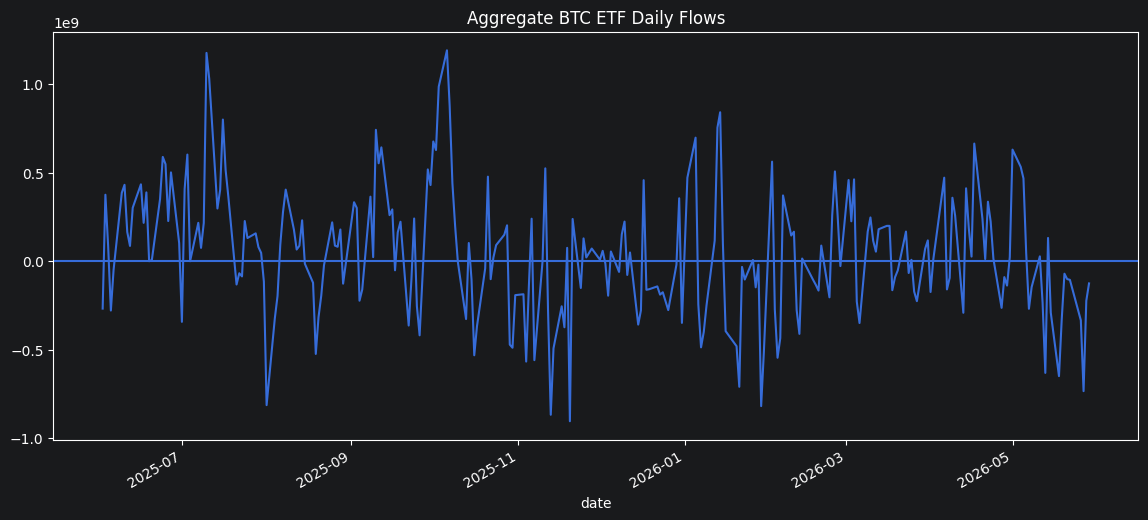

In [1753]:
# Visualize ETF Flows

etf_flows_recent['btc_etf_flow_usd'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('Aggregate BTC ETF Daily Flows')
plt.show()

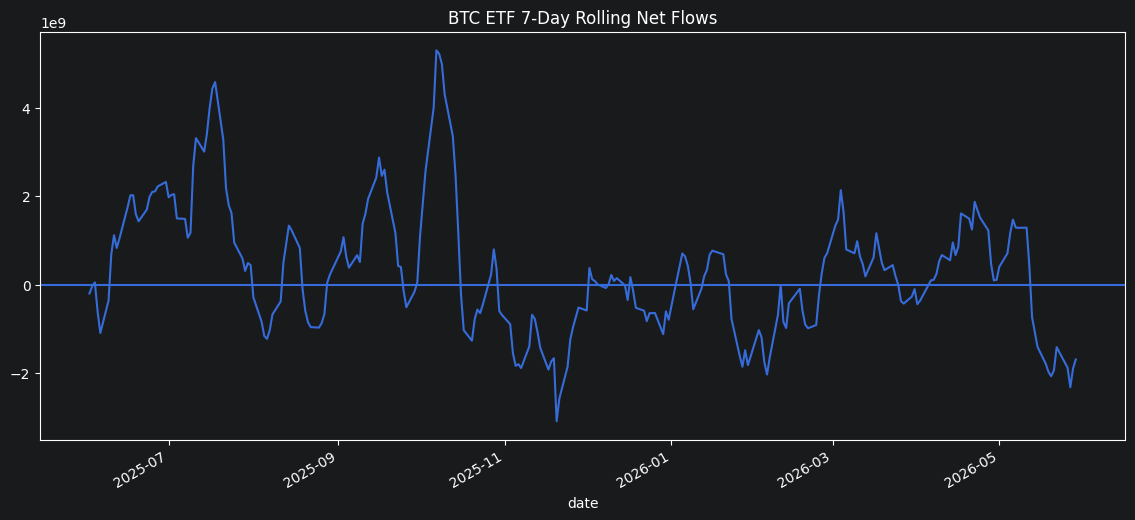

In [1782]:
etf_flows_recent['btc_etf_flow_7d'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC ETF 7-Day Rolling Net Flows')
plt.savefig(
    '../outputs/charts/rolling_etf_flows.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

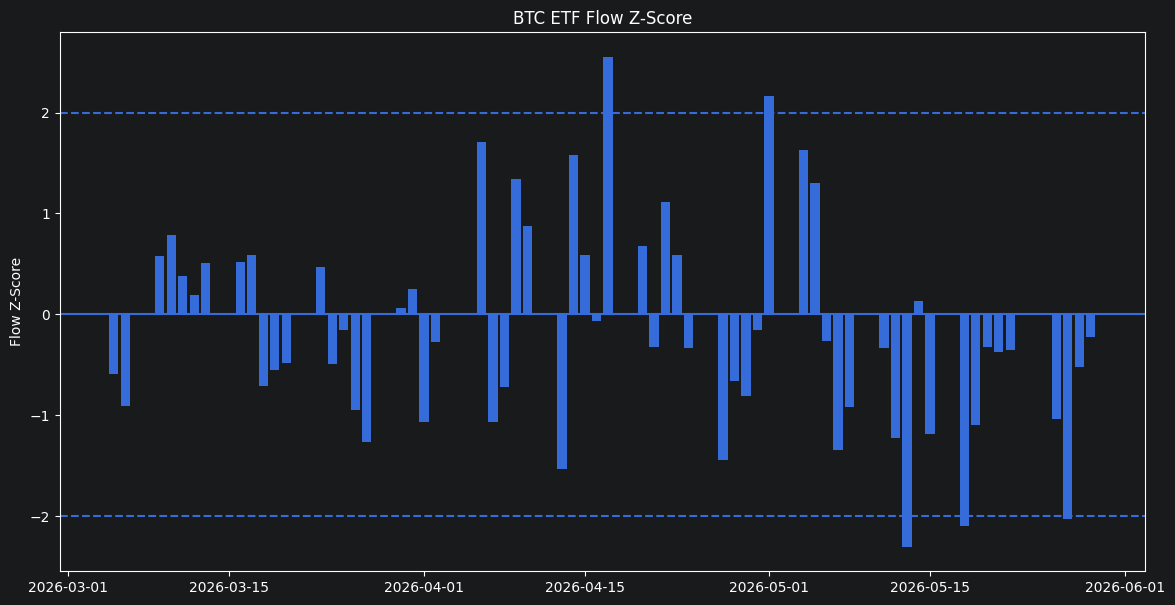

In [1781]:
# Recent ETF Flow Z-Scores

recent_flows = etf_flows_recent[['btc_etf_flow_zscore']].tail(60)

plt.figure(figsize=(14,7))

plt.bar(recent_flows.index, recent_flows['btc_etf_flow_zscore'])

plt.axhline(0)
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')

plt.title('BTC ETF Flow Z-Score')
plt.ylabel('Flow Z-Score')
plt.savefig(
    '../outputs/charts/etf_flow_zscore.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

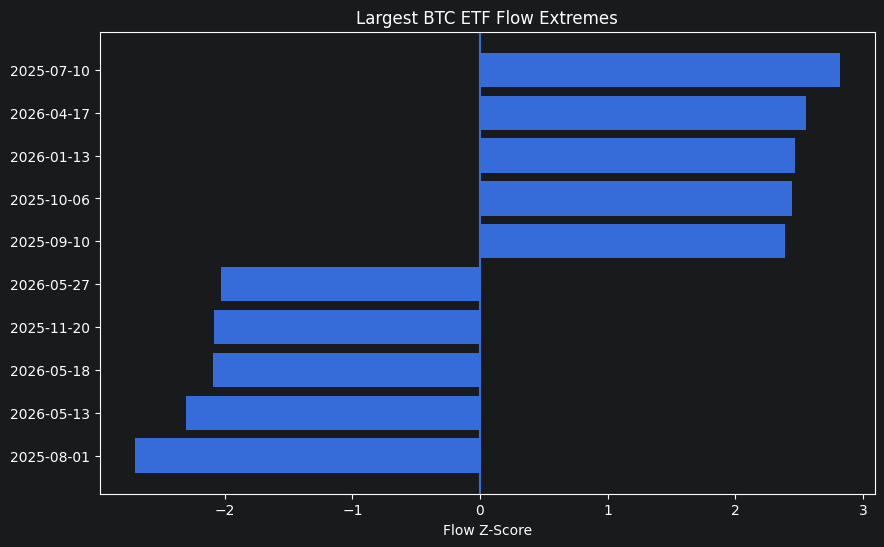

In [1780]:
# Largest Positive/Negative Flow Days

extreme_flows = etf_flows_recent[['btc_etf_flow_zscore']].dropna().sort_values(by='btc_etf_flow_zscore')

extreme_flows = pd.concat([
    extreme_flows.head(5),
    extreme_flows.tail(5)
])

plt.figure(figsize=(10,6))

plt.barh(extreme_flows.index.astype(str), extreme_flows['btc_etf_flow_zscore'])

plt.axvline(0)
plt.title('Largest BTC ETF Flow Extremes')
plt.xlabel('Flow Z-Score')
plt.show()

In [1757]:
# Merge ETF flows into prices

prices = prices.merge(etf_flows_recent[
        ['btc_etf_flow_usd',
        'btc_etf_flow_7d',
        'btc_etf_flow_30d',
        'btc_etf_flow_zscore']],
    on='date', how='left', validate='one_to_one'
)

In [1758]:
# Institutional Flow Regimes

prices['institutional_signal'] = 'Neutral'

prices.loc[
    prices['btc_etf_flow_zscore'] > 1.5,
    'institutional_signal'
] = 'Strong Institutional Inflows'

prices.loc[
    prices['btc_etf_flow_zscore'] < -1.5,
    'institutional_signal'
] = 'Institutional Outflows'

In [1759]:
# Plotting Market Drivers

# Start Neutral
prices['market_driver'] = 'Neutral'

# Lowest priority first
prices.loc[
    (prices['institutional_signal'] == 'Strong Institutional Inflows') &
    (prices['leverage_signal'] == 'Neutral'),
    'market_driver'
] = 'Spot-Led Institutional Demand'

prices.loc[
    (prices['institutional_signal'] == 'Neutral') &
    (prices['leverage_signal'] == 'Aggressive Long Buildup'),
    'market_driver'
] = 'Leverage-Driven Rally'

# Higher priority
prices.loc[
    (prices['institutional_signal'] == 'Strong Institutional Inflows') &
    (prices['leverage_signal'] == 'Aggressive Long Buildup'),
    'market_driver'
] = 'Institutional + Leverage Momentum'

# Highest priority LAST
prices.loc[
    (prices['institutional_signal'] == 'Institutional Outflows') |
    (prices['leverage_signal'] == 'Long Liquidation'),
    'market_driver'
] = 'Risk-Off / Deleveraging'

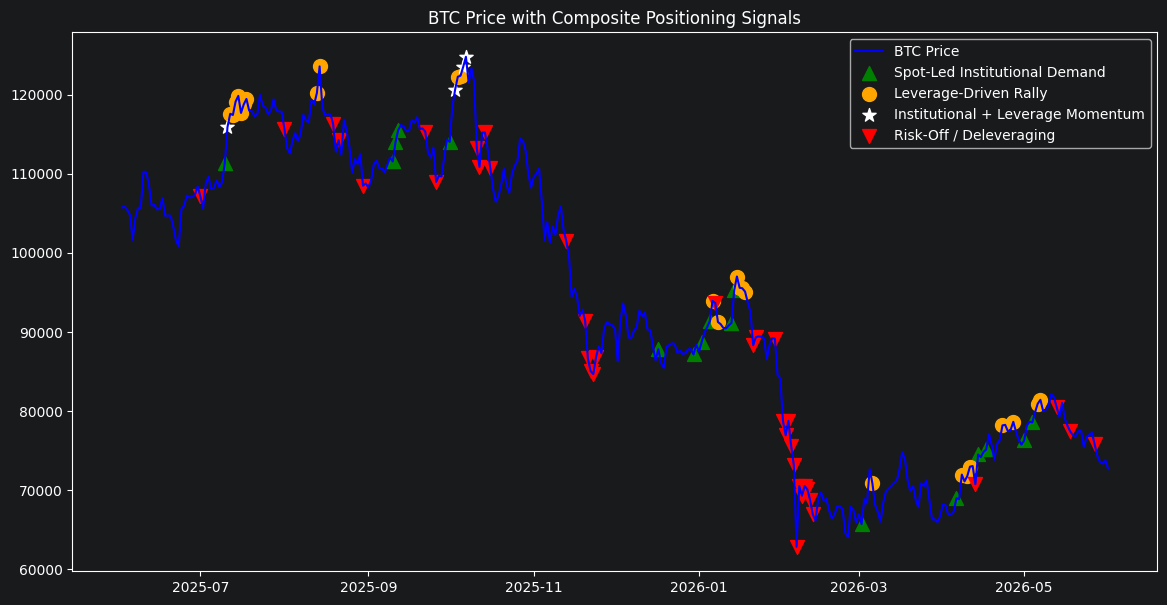

In [1783]:
signal_df = prices[prices['market_driver'] != 'Neutral']

plt.figure(figsize=(14,7))

plt.plot(prices.index, prices['price'], color='blue', label='BTC Price')

marker_map = {
    'Spot-Led Institutional Demand': ('^', 'green'),
    'Leverage-Driven Rally': ('o', 'orange'),
    'Institutional + Leverage Momentum': ('*', 'white'),
    'Risk-Off / Deleveraging': ('v', 'red')
}

for signal, (marker, color) in marker_map.items():
    subset = signal_df[signal_df['market_driver'] == signal]

    plt.scatter(
        subset.index,
        subset['price'],
        label=signal,
        marker=marker,
        color=color,
        s=100
    )

plt.title('BTC Price with Composite Positioning Signals')
plt.legend()
plt.savefig(
    '../outputs/charts/composite_positioning_signals.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [1761]:
# 6. Run conditional forward-return analysis

prices['forward_7d_return'] = (prices['price'].shift(-7) / prices['price']) - 1
prices['forward_30d_return'] = (prices['price'].shift(-30) / prices['price']) - 1

In [1762]:
strong_etf_inflows = prices[
    prices['btc_etf_flow_zscore'] > 1.5
]

In [1763]:
# What Happens after Aggressive Long Buildup?
long_buildup = prices[prices['leverage_signal'] == 'Aggressive Long Buildup']

In [1764]:
# Long Liquidation
long_liquidation = prices[prices['leverage_signal'] == 'Long Liquidation']

In [1765]:
# Short Buildup
short_buildup = prices[prices['leverage_signal'] == 'Aggressive Short Buildup']

In [1766]:
# Short Covering
short_covering = prices[prices['leverage_signal'] == 'Short Covering Rally']

In [1767]:
etf_median = strong_etf_inflows[['forward_7d_return', 'forward_30d_return']].median()
long_median = long_buildup[['forward_7d_return', 'forward_30d_return']].median()
long_liquidation_median = long_liquidation[['forward_7d_return', 'forward_30d_return']].median()
short_buildup_median = short_buildup[['forward_7d_return', 'forward_30d_return']].median()
short_covering_median = short_covering[['forward_7d_return', 'forward_30d_return']].median()

print(
    f"Strong ETF Inflows | "
    f"Median 7D: {etf_median['forward_7d_return']:.2%} | "
    f"Median 30D: {etf_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Long Buildup | "
    f"Median 7D: {long_median['forward_7d_return']:.2%} | "
    f"Median 30D: {long_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Long Liquidation | "
    f"Median 7D: {long_liquidation_median['forward_7d_return']:.2%} | "
    f"Median 30D: {long_liquidation_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Short Buildup | "
    f"Median 7D: {short_buildup_median['forward_7d_return']:.2%} | "
    f"Median 30D: {short_buildup_median['forward_30d_return']:.2%}"
)

print(
    f"Short Covering Rally | "
    f"Median 7D: {short_covering_median['forward_7d_return']:.2%} | "
    f"Median 30D: {short_covering_median['forward_30d_return']:.2%}"
)

Strong ETF Inflows | Median 7D: 2.00% | Median 30D: -3.32%
Aggressive Long Buildup | Median 7D: -1.24% | Median 30D: -4.47%
Aggressive Long Liquidation | Median 7D: -1.88% | Median 30D: -3.57%
Aggressive Short Buildup | Median 7D: 3.24% | Median 30D: -12.10%
Short Covering Rally | Median 7D: -1.74% | Median 30D: -3.62%


In [1768]:
# Summary of Signals

signal_summary = pd.DataFrame({
    'signal': [
        'Strong ETF Inflows',
        'Aggressive Long Buildup',
        'Long Liquidation',
        'Aggressive Short Buildup',
        'Short Covering Rally'
    ],
    'count': [
        len(strong_etf_inflows),
        len(long_buildup),
        len(long_liquidation),
        len(short_buildup),
        len(short_covering)
    ],
    'median_7d_return': [
        strong_etf_inflows['forward_7d_return'].median(),
        long_buildup['forward_7d_return'].median(),
        long_liquidation['forward_7d_return'].median(),
        short_buildup['forward_7d_return'].median(),
        short_covering['forward_7d_return'].median()
    ],
    'median_30d_return': [
        strong_etf_inflows['forward_30d_return'].median(),
        long_buildup['forward_30d_return'].median(),
        long_liquidation['forward_30d_return'].median(),
        short_buildup['forward_30d_return'].median(),
        short_covering['forward_30d_return'].median()
    ]
})

In [1769]:
signal_summary_raw = signal_summary.copy()
signal_summary_display = signal_summary.copy()

In [1770]:
signal_summary_display = signal_summary_display.sort_values('median_7d_return', ascending=False).reset_index(drop=True)

signal_summary_display['median_7d_return'] = signal_summary_display['median_7d_return'].map('{:.2%}'.format)
signal_summary_display['median_30d_return'] = signal_summary_display['median_30d_return'].map('{:.2%}'.format)

print(signal_summary_display)

                     signal  count median_7d_return median_30d_return
0  Aggressive Short Buildup      8            3.24%           -12.10%
1        Strong ETF Inflows     22            2.00%            -3.32%
2   Aggressive Long Buildup     30           -1.24%            -4.47%
3      Short Covering Rally     14           -1.74%            -3.62%
4          Long Liquidation     25           -1.88%            -3.57%


In [1776]:
import os

print(os.getcwd())

import os

print(os.path.exists('outputs'))
print(os.path.exists('outputs/charts'))

import os

print(os.listdir())

/Users/nate/PycharmProjects/PythonProject/positioning_monitor/notebooks
False
False
['btc_positioning_monitor.html', 'btc_positioning_monitor.ipynb']


In [1777]:
import os

print(os.path.exists('../outputs'))
print(os.path.exists('../outputs/charts'))

True
True


In [1784]:
import os

print(os.listdir('../outputs/charts'))

['leverage_regime_signals.png', 'etf_flow_zscore.png', 'rolling_etf_flows.png', 'composite_positioning_signals.png']
